FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


 ДЕРЕВО МЕТРИК (ИЕРАРХИЯ)

MOVIELENS METRICS
|
+-- ENGAGEMENT (Вовлеченность)
|   +-- DAU (Ср. кол-во пользователей в день): 162
|   +-- Ratings/User (Ср. оценок на чел.): 153.8
|   +-- Movies/User (Ср. фильмов на чел.): 153.8
|
+-- QUALITY (Качество контента)
|   +-- Avg Rating (Средняя оценка): 3.53
|   +-- Median Rating (Медиана): 3.5
|   +-- Polarization (Поляризация мнений): 1.00
|
+-- RETENTION (Удержание)
    +-- Day-1 Retention (Возврат через день): 18.8%
    +-- Day-7 Retention (Возврат за неделю): 100.0%
    +-- Churn Rate (Отток): 81.2%



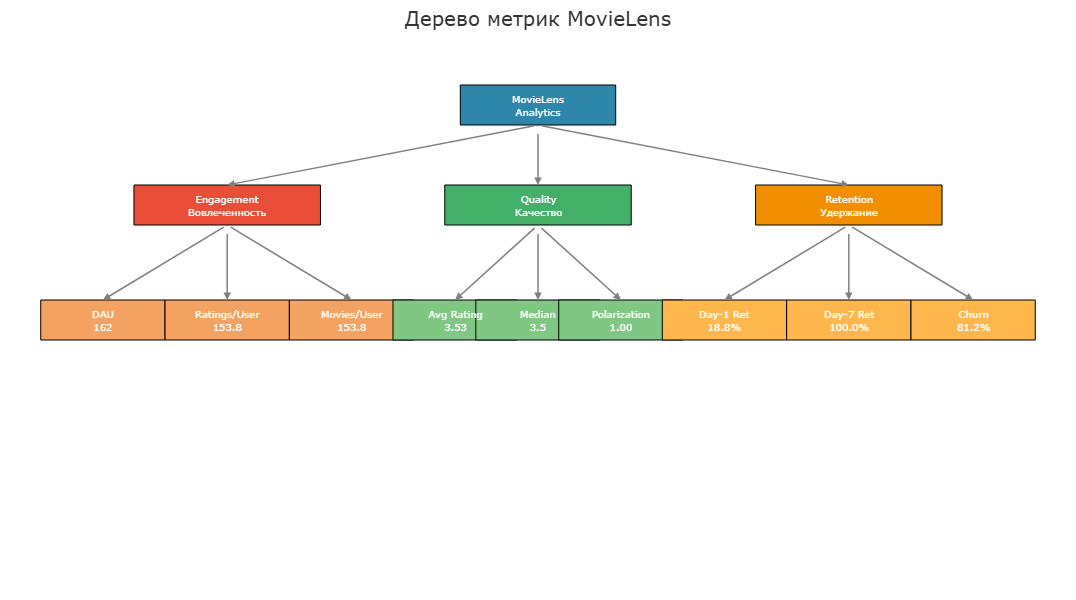

In [17]:
# %%
import duckdb
from pathlib import Path
import pandas as pd
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

con = duckdb.connect()


data_dir = Path(r'C:\Users\Мартинсон Диана\metric tree\data\raw\ml-25m')
ratings_path = data_dir / 'ratings.csv'
movies_path = data_dir / 'movies.csv'

# Проверка файлов
if not ratings_path.exists() or not movies_path.exists():
    raise FileNotFoundError(f"Файлы не найдены в папке: {data_dir}")


con.execute(f"CREATE TABLE IF NOT EXISTS raw_ratings AS SELECT * FROM read_csv_auto('{ratings_path}')")
con.execute(f"CREATE TABLE IF NOT EXISTS raw_movies AS SELECT * FROM read_csv_auto('{movies_path}')")


con.execute("""
    CREATE TABLE IF NOT EXISTS user_activity AS
    SELECT 
        r.userId, r.movieId, r.rating, r.timestamp,
        to_timestamp(r.timestamp) AS datetime,
        CAST(to_timestamp(r.timestamp) AS DATE) AS date,
        m.title, m.genres
    FROM raw_ratings r
    LEFT JOIN raw_movies m ON r.movieId = m.movieId
""")


# РАСЧЕТ МЕТРИК

# --- Engagement (Вовлеченность) ---
dau_stats = con.execute("""
    SELECT AVG(daily_users) as avg_dau 
    FROM (SELECT date, COUNT(DISTINCT userId) as daily_users FROM user_activity GROUP BY date)
""").fetchone()[0]

avg_ratings_per_user = con.execute("""
    SELECT AVG(user_ratings) FROM (SELECT userId, COUNT(*) as user_ratings FROM raw_ratings GROUP BY userId)
""").fetchone()[0]

avg_movies_per_user = con.execute("""
    SELECT AVG(user_movies) FROM (SELECT userId, COUNT(DISTINCT movieId) as user_movies FROM raw_ratings GROUP BY userId)
""").fetchone()[0]

# --- Quality (Качество) ---
avg_rating = con.execute("SELECT ROUND(AVG(rating), 2) FROM raw_ratings").fetchone()[0]
median_rating = con.execute("SELECT ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY rating), 2) FROM raw_ratings").fetchone()[0]
polarization = con.execute("""
    SELECT AVG(std_dev) FROM (
        SELECT movieId, STDDEV(rating) as std_dev 
        FROM raw_ratings GROUP BY movieId HAVING COUNT(*) >= 10
    )
""").fetchone()[0]

# --- Retention (Удержание) ---
retention_d1 = con.execute("""
    WITH user_first AS (
        SELECT userId, MIN(date) as first_day 
        FROM user_activity 
        GROUP BY userId
    ),
    retention_check AS (
        SELECT ufd.userId, 
               MAX(CASE WHEN ua.date = ufd.first_day + INTERVAL '1 day' THEN 1 ELSE 0 END) as ret 
        FROM user_first ufd 
        LEFT JOIN user_activity ua ON ufd.userId = ua.userId 
        GROUP BY ufd.userId
    )
    SELECT ROUND(SUM(ret) * 100.0 / COUNT(*), 1) FROM retention_check
""").fetchone()[0]

retention_d7 = con.execute("""
    WITH user_first AS (
        SELECT userId, MIN(date) as first_day 
        FROM user_activity 
        GROUP BY userId
    ),
    retention_check AS (
        SELECT ufd.userId, 
               MAX(CASE WHEN ua.date BETWEEN ufd.first_day AND ufd.first_day + INTERVAL '6 days' THEN 1 ELSE 0 END) as ret 
        FROM user_first ufd 
        LEFT JOIN user_activity ua ON ufd.userId = ua.userId 
        GROUP BY ufd.userId
    )
    SELECT ROUND(SUM(ret) * 100.0 / COUNT(*), 1) FROM retention_check
""").fetchone()[0]

churn_rate = 100 - retention_d1



print("\n ДЕРЕВО МЕТРИК (ИЕРАРХИЯ)")


tree_text = f"""
MOVIELENS METRICS
|
+-- ENGAGEMENT (Вовлеченность)
|   +-- DAU (Ср. кол-во пользователей в день): {dau_stats:,.0f}
|   +-- Ratings/User (Ср. оценок на чел.): {avg_ratings_per_user:.1f}
|   +-- Movies/User (Ср. фильмов на чел.): {avg_movies_per_user:.1f}
|
+-- QUALITY (Качество контента)
|   +-- Avg Rating (Средняя оценка): {avg_rating}
|   +-- Median Rating (Медиана): {median_rating}
|   +-- Polarization (Поляризация мнений): {polarization:.2f}
|
+-- RETENTION (Удержание)
    +-- Day-1 Retention (Возврат через день): {retention_d1}%
    +-- Day-7 Retention (Возврат за неделю): {retention_d7}%
    +-- Churn Rate (Отток): {churn_rate:.1f}%
"""

print(tree_text)


import plotly.graph_objects as go
import plotly.io as pio


nodes = [
    # Корень
    {"x": 0.5, "y": 0.95, "text": "MovieLens<br>Analytics", "color": "#2E86AB", "width": 0.15},
    # Уровень 1 - категории
    {"x": 0.2, "y": 0.75, "text": "Engagement<br>Вовлеченность", "color": "#E94F37", "width": 0.18},
    {"x": 0.5, "y": 0.75, "text": "Quality<br>Качество", "color": "#44AF69", "width": 0.18},
    {"x": 0.8, "y": 0.75, "text": "Retention<br>Удержание", "color": "#F18F01", "width": 0.18},
    # Уровень 2 - Engagement
    {"x": 0.08, "y": 0.52, "text": f"DAU<br>{dau_stats:,.0f}", "color": "#F4A261", "width": 0.12},
    {"x": 0.2, "y": 0.52, "text": f"Ratings/User<br>{avg_ratings_per_user:.1f}", "color": "#F4A261", "width": 0.12},
    {"x": 0.32, "y": 0.52, "text": f"Movies/User<br>{avg_movies_per_user:.1f}", "color": "#F4A261", "width": 0.12},
    # Уровень 2 - Quality
    {"x": 0.42, "y": 0.52, "text": f"Avg Rating<br>{avg_rating}", "color": "#81C784", "width": 0.12},
    {"x": 0.5, "y": 0.52, "text": f"Median<br>{median_rating}", "color": "#81C784", "width": 0.12},
    {"x": 0.58, "y": 0.52, "text": f"Polarization<br>{polarization:.2f}", "color": "#81C784", "width": 0.12},
    # Уровень 2 - Retention
    {"x": 0.68, "y": 0.52, "text": f"Day-1 Ret<br>{retention_d1}%", "color": "#FFB74D", "width": 0.12},
    {"x": 0.8, "y": 0.52, "text": f"Day-7 Ret<br>{retention_d7}%", "color": "#FFB74D", "width": 0.12},
    {"x": 0.92, "y": 0.52, "text": f"Churn<br>{churn_rate:.1f}%", "color": "#FFB74D", "width": 0.12},
]

fig = go.Figure()


for node in nodes:
    fig.add_shape(
        type="rect",
        x0=node["x"] - node["width"]/2,
        y0=node["y"] - 0.04,
        x1=node["x"] + node["width"]/2,
        y1=node["y"] + 0.04,
        fillcolor=node["color"],
        line=dict(color="black", width=1),
    )
    fig.add_annotation(
        x=node["x"],
        y=node["y"],
        text=node["text"],
        showarrow=False,
        font=dict(size=10, color="white"),
    )


connections = [
    # Корень -> Категории
    (0.5, 0.91, 0.2, 0.79),
    (0.5, 0.91, 0.5, 0.79),
    (0.5, 0.91, 0.8, 0.79),
    # Engagement -> метрики
    (0.2, 0.71, 0.08, 0.56),
    (0.2, 0.71, 0.2, 0.56),
    (0.2, 0.71, 0.32, 0.56),
    # Quality -> метрики
    (0.5, 0.71, 0.42, 0.56),
    (0.5, 0.71, 0.5, 0.56),
    (0.5, 0.71, 0.58, 0.56),
    # Retention -> метрики
    (0.8, 0.71, 0.68, 0.56),
    (0.8, 0.71, 0.8, 0.56),
    (0.8, 0.71, 0.92, 0.56),
]

for x1, y1, x2, y2 in connections:
    fig.add_annotation(
        x=x2, y=y2,
        ax=x1, ay=y1,
        xref="x", yref="y",
        axref="x", ayref="y",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=1.5,
        arrowcolor="gray",
    )

# Настройки графика
fig.update_layout(
    title={
        "text": "Дерево метрик MovieLens",
        "y": 0.98,
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top",
        "font": dict(size=20, color="#333")
    },
    xaxis=dict(range=[0, 1], visible=False),
    yaxis=dict(range=[0, 1], visible=False),
    height=600,
    margin=dict(t=80, l=20, r=20, b=20),
    plot_bgcolor="white",
    showlegend=False,
)

fig.show()